In [48]:
import numpy as np
from itertools import pairwise
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import load_breast_cancer
from sklearn.datasets import load_iris

'''
x = np.array([1,2,3,4,5])
y = np.array([5,7,9,11,13])
'''
df = pd.read_csv('./public/gd.csv')
x = df.iloc[:, 0].values
y = df.iloc[:, 1].values

df = pd.read_csv("./public/iris.data")
df["CLASS"] = le.fit_transform(df["CLASS"])


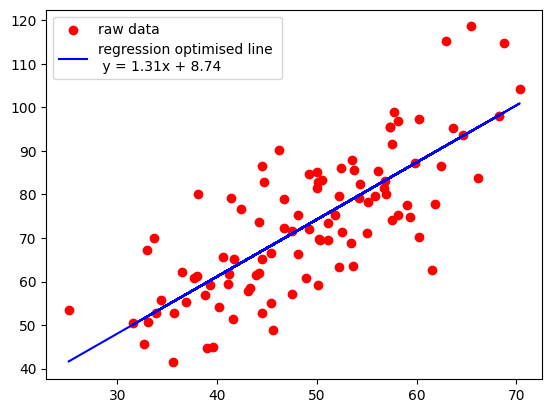

y_values : [ 68.77759598  62.5623823   71.54663223  87.23092513  78.21151827
  79.64197305  59.17148932  75.3312423   71.30087989  55.16567715
  82.47884676  62.00892325  75.39287043  81.43619216  60.72360244
  82.89250373  97.37989686  48.84715332  56.87721319  83.87856466
 118.5912173   57.25181946  51.39174408  75.38065167  74.76556403
  95.45505292  95.22936602  79.05240617  83.43207142  63.35879032
  41.4128853   76.61734128  96.76956643  74.08413012  66.58814441
  77.76848242  50.71958891  62.12457082  60.81024665  52.68298337
  58.56982472  82.90598149  61.4247098  115.2441528   45.57058882
  54.0840548   87.99445276  52.72549438  93.57611869  80.16627545
  65.10171157  65.56230126  65.28088692  73.43464155  71.13972786
  79.10282968  86.52053844  84.74269781  59.35885025  61.68403752
  69.84760416  86.09829121  59.10883927  69.89968164  44.86249071
  85.49806778  95.53668685  70.25193442  52.72173496  50.39267014
  63.64239878  72.24725107  57.81251298 104.25710159  86.64202032

In [170]:
# 1. gradient descent linear regression fn = linear relationship btw 2 datsets (X and Y), cotinuous output 
def graddes(x, y, l_rate, epochs):
    m = c = 0 
    n = len(x)
    mse = list()
    for i in range(epochs):
        y_pred = (m*x) + c #numpy array of all values
        cf = (1/n) * sum((y_pred - y)**2)
        grad_m = (2/n) * sum(-x*(y_pred - y))
        grad_c = (2/n) * sum(-1*(y_pred - y))

        m += l_rate * grad_m
        c += l_rate * grad_c
        if i % 100 == 0 or i == epochs - 1:
            mse.append(round(cf,6))
    is_decreasing = all(i >= j for i, j in pairwise(mse))
    return (y_pred, m, c) if is_decreasing else (np.zeros(n),0,0)

(y_pred, m, c) = graddes(x, y, l_rate=0.00029, epochs=100000)

plt.scatter(x,y,color="red", label="raw data")
plt.plot(x,y_pred,color="blue", label=f"regression optimised line \n y = {round(m,2)}x + {round(c,2)}")
plt.legend()
plt.show()

print(f"y_values : {y}")
print(f"y_pred : {y_pred}")

In [171]:
#model.fit(x.reshape(-1, 1), y) # x = [[1], [2], [3]] internally evaluated as a vertical column or 3 samples of feature x 
model = LinearRegression()
model.fit(x.reshape(-1,1),y)
print(f"y = {round(model.coef_[0], 2)}x + {round(model.intercept_, 2)}")

y = 1.29x + 9.91


In [179]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression() #linear regressor 
model.fit(x_train.reshape(-1,1),y_train)
y_pred = model.predict(x_test.reshape(-1,1))

#finding residuals (regrssion metrics)
print(f"Minimized mean-squared-error : {mean_squared_error(y_test, y_pred)}")
print("MAE", mean_absolute_error(y_test,y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test,y_pred)))

model.predict([[5.9]]) #[ [5.9] ] represents the row 

Minimized mean-squared-error : 69.24927307794563
MAE 6.785645810167421
RMSE 8.321614811918757


array([20.84931717])

In [25]:
#3. SVM - Multiclass classification
x_train, x_test, y_train, y_test = train_test_split(df[["SL", "SW", "PL", "PW"]], df["CLASS"], test_size=0.3, random_state=42, stratify=df["CLASS"])
model = SVC(kernel="linear") #linear (100%), rbf (95.55), sigmoid (4.44), poly (95.55)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print(model.get_params())
print(f"\n y_test : \n {y_test.values}\n y_pred : \n{y_pred}")

#classification metrics 
print("\nConfusion Matrix \n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(f"Accuracy score : {accuracy_score(y_test, y_pred)*100}%")


{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}

 y_test : 
 [2 1 2 1 2 2 1 1 0 2 0 0 2 2 0 2 1 0 0 0 1 0 1 2 2 1 1 1 1 0 2 2 1 0 2 0 0
 0 0 1 1 0 2 2 1]
 y_pred : 
[2 1 2 1 2 2 1 1 0 2 0 0 2 2 0 2 1 0 0 0 1 0 1 2 2 1 1 1 1 0 2 2 1 0 2 0 0
 0 0 1 1 0 2 2 1]

Confusion Matrix 
 [[15  0  0]
 [ 0 15  0]
 [ 0  0 15]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Accuracy score : 100.0%


In [30]:
# 2. Logistic Classification - Binary classification ie benign/malignant (signmoid decision boundary line) (Binary logistic regression)
# activation fn : signmoid
# Decision Boundary: By default, Scikit-learn uses a 0.5 threshold; if the predicted probability is \(>0.5\), the model assigns the data point to class 1
# Logistic regression applies the sigmoid function to map linear outputs to a probability range between 0 and 1.
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(solver='liblinear', max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.96

Confusion Matrix:
 [[39  4]
 [ 1 70]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [44]:
# Multi-class classification 
# Creates a binary classifier for each class against the others and models all class simulataniously using multiclass=multinomial (soft-max multinomial regression)
# activation function = softmax
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(solver='lbfgs', max_iter=200)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Accuracy: 1.00


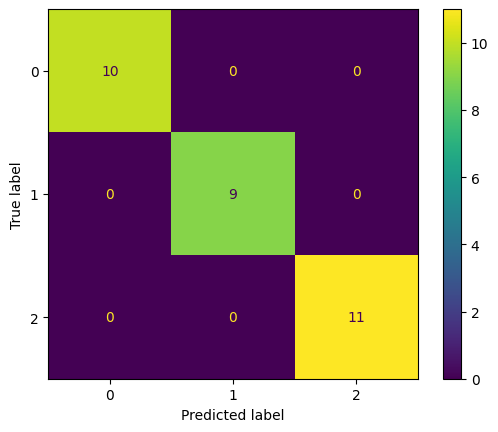

In [49]:
y_pred = model.predict(X_test)
print(f"Accuracy: {model.score(X_test, y_test):.2f}")
#sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred), display_labels=model.classes_)
disp.plot()
plt.show()